In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

In [ ]:
folder_path = 'data/Files for ML'
files = glob.glob(os.path.join(folder_path, '*.txt'))
print( f"founded {len(files)} files")

founded 103 files


## LOADING DATA
First thing, we prepare the new features based on the information of each data file: ID, SEX for the subject and NATURE for the faces. In addition we clearly state the time-scale of the EEG, with a new feature "SampleIndex"

In [ ]:
ls = []
for file in files:
    f_name = os.path.basename(file).replace('.txt', '')

    temp_df = pd.read_csv(file, sep= r'\s+', engine='python')

    temp_df['SubjectID'] = f_name[:2]

    temp_df['SubjectSEX'] = f_name[2]

    temp_df['TargetCODE'] = f_name[7:]

    temp_df["TargetNATURE"] = f_name [9]

    temp_df['SampleIndex'] = temp_df.index

    ls.append(temp_df)
    print(f"Caricato file: {f_name}")

dataset_fin = pd.concat(ls, ignore_index=True)

print(f"Dimensioni totali del dataset: {dataset_fin.shape}")

Caricato file: 07FAvg-70RM
Caricato file: 09FAvg-60AF
Caricato file: 25MAvg-50AM
Caricato file: 08FAvg-50AM
Caricato file: 21MAvg-60AF
Caricato file: 08FAvg-80RF
Caricato file: 19FAvg-60AF
Caricato file: 10FAvg-60AF
Caricato file: 17MAvg-70RM
Caricato file: 09FAvg-80RF
Caricato file: 05FAvg-80RF
Caricato file: 27FAvg-50AM
Caricato file: 22MAvg-50AM
Caricato file: 10FAvg-80RF
Caricato file: 08FAvg-70RM
Caricato file: 05FAvg-70RM
Caricato file: 07FAvg-50AM
Caricato file: 16FAvg-50AM
Caricato file: 04FAvg-50AM
Caricato file: 04FAvg-70RM
Caricato file: 01FAvg-80RF
Caricato file: 22MAvg-70RM
Caricato file: 20MAvg-60AF
Caricato file: 22MAvg-80RF
Caricato file: 07FAvg-60AF
Caricato file: 02FAvg-60AF
Caricato file: 19FAvg-50AM
Caricato file: 15FAvg-60AF
Caricato file: 18FAvg-60AF
Caricato file: 09FAvg-70RM
Caricato file: 01FAvg-60AF
Caricato file: 13MAvg-60AF
Caricato file: 11MAvg-60AF
Caricato file: 06MAvg-50AM
Caricato file: 21MAvg-50AM
Caricato file: 16FAvg-60AF
Caricato file: 02FAvg-70RM
C

In [ ]:
dataset_fin

,Fp1,Fpz,Fp2,AF3,AF4,F11,F7,F5,F3,F1,...,PO10,Cbz,VEOG,HEOG,Trigger,SubjectID,SubjectSEX,TargetCODE,TargetNATURE,SampleIndex
0,-0.991290,-0.20452,0.095646,0.880510,1.66750,-1.139200,-0.18446,-0.606380,-0.001194,0.348230,...,-0.586040,-1.27310,1.925900,0.26638,0.000000,07,F,70RM,R,0
1,-0.878980,-0.44495,-0.160040,0.809270,1.60010,-1.157800,-0.25250,-0.588300,-0.137970,0.199470,...,-0.428230,-1.17350,0.843210,0.64600,0.000000,07,F,70RM,R,1
2,-0.553630,-0.55492,-0.298430,0.515940,1.37210,-1.121000,-0.29774,-0.478280,-0.251440,0.066234,...,-0.249830,-1.00400,-0.052422,0.72622,0.000000,07,F,70RM,R,2
3,-0.047023,-0.48712,-0.290870,0.058814,1.03610,-1.041000,-0.32523,-0.291360,-0.317870,-0.027340,...,-0.054926,-0.76857,1.146000,0.63330,0.000000,07,F,70RM,R,3
4,0.590610,-0.27857,-0.133400,-0.449410,0.65227,-0.887730,-0.30862,-0.042555,-0.329860,-0.071732,...,0.114070,-0.50375,1.236000,0.55590,0.000000,07,F,70RM,R,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46448,-2.081300,-1.77770,-1.543400,-0.525720,-0.86184,-0.058895,1.45970,-0.547430,-2.185600,-0.355040,...,0.058113,2.77410,-6.412200,4.97480,-0.003237,28,M,70RM,R,446
46449,-2.078500,-1.79100,-1.562200,-0.518770,-0.90451,0.010689,1.48590,-0.626970,-2.215200,-0.325830,...,0.010014,2.81640,-4.312900,5.18160,-0.003237,28,M,70RM,R,447
46450,-2.088300,-1.77330,-1.540600,-0.522770,-0.93754,0.039952,1.50990,-0.709820,-2.263000,-0.304000,...,-0.018443,2.83950,-4.818600,4.88080,-0.003237,28,M,70RM,R,448
46451,-2.100400,-1.72280,-1.494200,-0.531290,-0.97645,0.044865,1.53820,-0.770940,-2.312700,-0.285650,...,-0.032462,2.87480,-5.317800,5.16970,-0.003237,28,M,70RM,R,449


We do not need to use all the channels. We choose the most meaningful

In [ ]:
selected_columns = ['O1', 'O2', 'PO9', 'PO10', 'TP7', 'TP8', 'P3', 'P4', 'AF3', 'AF4', 'AFF1h', 'AFF2h', 'AFF3h', 'AFF4h', 'Trigger', 'SubjectID', 'SubjectSEX', 'TargetCODE', 'TargetNATURE', 'SampleIndex']
dataset_filtered = dataset_fin[selected_columns]


In [ ]:
display(dataset_filtered)

,O1,O2,PO9,PO10,TP7,TP8,P3,P4,AF3,AF4,AFF1h,AFF2h,AFF3h,AFF4h,Trigger,SubjectID,SubjectSEX,TargetCODE,TargetNATURE,SampleIndex
0,-0.97065,-0.715790,-0.99965,-0.586040,-0.42319,0.069254,-0.104790,0.62930,0.880510,1.66750,0.668460,0.84865,0.001661,0.72168,0.000000,07,F,70RM,R,0
1,-0.78150,-0.520910,-0.75048,-0.428230,-0.45123,0.029717,-0.033953,0.66714,0.809270,1.60010,0.547040,0.83390,-0.223000,0.96600,0.000000,07,F,70RM,R,1
2,-0.62601,-0.324540,-0.54748,-0.249830,-0.49296,0.071605,0.012952,0.67694,0.515940,1.37210,0.387480,0.76601,-0.405010,1.17630,0.000000,07,F,70RM,R,2
3,-0.51884,-0.134890,-0.42429,-0.054926,-0.51994,0.134210,0.023341,0.65104,0.058814,1.03610,0.222410,0.65024,-0.483990,1.27840,0.000000,07,F,70RM,R,3
4,-0.48933,0.001017,-0.39660,0.114070,-0.50726,0.249210,-0.017268,0.59139,-0.449410,0.65227,0.083929,0.50507,-0.473970,1.24400,0.000000,07,F,70RM,R,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46448,-1.70950,1.267000,-1.37890,0.058113,-0.65591,1.632200,-0.446360,1.37410,-0.525720,-0.86184,1.110100,0.92197,-0.494400,-0.96917,-0.003237,28,M,70RM,R,446
46449,-1.61420,1.168400,-1.33810,0.010014,-0.46878,1.432800,-0.392940,1.24600,-0.518770,-0.90451,1.058100,0.92126,-0.493450,-0.96093,-0.003237,28,M,70RM,R,447
46450,-1.53300,1.114400,-1.31890,-0.018443,-0.32054,1.290900,-0.353290,1.15450,-0.522770,-0.93754,0.987560,0.95822,-0.504630,-0.95811,-0.003237,28,M,70RM,R,448
46451,-1.44250,1.102500,-1.29690,-0.032462,-0.21285,1.192200,-0.319830,1.09030,-0.531290,-0.97645,0.909790,1.02540,-0.516420,-0.95775,-0.003237,28,M,70RM,R,449


## INTERPRETATION
Each sample index represents a step in time, each step is equal to 2 ms (since we have 450 steps for person and a window from -100ms to 800ms). We need to focus between 200ms and 600ms, as seen in past literature and publications


In [ ]:
dataset_filtered = dataset_filtered[(dataset_filtered['SampleIndex'] >= 150) & (dataset_filtered['SampleIndex'] <= 350)]
display(dataset_filtered.head())

,O1,O2,PO9,PO10,TP7,TP8,P3,P4,AF3,AF4,AFF1h,AFF2h,AFF3h,AFF4h,Trigger,SubjectID,SubjectSEX,TargetCODE,TargetNATURE,SampleIndex
150,-1.23480,0.012061,-0.74995,1.4364,0.17042,-0.98605,1.5388,1.4927,0.74576,-2.1766,-0.54548,-1.5567,0.86463,-2.1700,0.0,07,F,70RM,R,150
151,-0.20897,0.506880,0.34865,2.1198,0.56051,-0.96014,1.7080,1.4265,-0.10417,-2.1404,-0.83816,-1.7577,0.35893,-2.1474,0.0,07,F,70RM,R,151
152,0.85957,1.163800,1.45930,2.9194,0.90930,-0.83234,1.9025,1.4362,-1.12070,-2.0882,-1.15140,-1.9768,-0.16184,-2.0869,0.0,07,F,70RM,R,152
153,1.93550,2.032100,2.51960,3.8664,1.20140,-0.65317,2.1268,1.5297,-2.11440,-2.0863,-1.48980,-2.2249,-0.65774,-2.0655,0.0,07,F,70RM,R,153
154,2.96070,3.082100,3.48210,4.9345,1.42440,-0.37813,2.3743,1.7078,-2.90160,-2.1978,-1.85540,-2.5032,-1.14530,-2.1275,0.0,07,F,70RM,R,154


In [ ]:
reportID = dataset_filtered[(dataset_filtered['SubjectID'] == '01')]
display(reportID)

,O1,O2,PO9,PO10,TP7,TP8,P3,P4,AF3,AF4,AFF1h,AFF2h,AFF3h,AFF4h,Trigger,SubjectID,SubjectSEX,TargetCODE,TargetNATURE,SampleIndex
9170,0.79055,3.3945,-3.866700,0.79344,-3.55240,0.093178,-0.80635,2.1601,-1.7503,-0.54402,-0.16434,-0.30799,-1.0373,-0.50766,0.0,01,F,80RF,R,150
9171,1.33710,3.9682,-3.408900,1.32710,-3.36260,0.083815,-0.67691,2.2439,-1.8230,-0.78557,-0.36493,-0.52788,-1.1498,-0.81567,0.0,01,F,80RF,R,151
9172,1.85830,4.5229,-3.004600,1.85290,-3.16100,0.124910,-0.55399,2.3300,-1.8755,-0.99836,-0.55809,-0.72351,-1.2163,-1.10300,0.0,01,F,80RF,R,152
9173,2.35540,5.0593,-2.640300,2.36860,-2.94800,0.208410,-0.42649,2.4363,-1.9661,-1.19950,-0.75357,-0.92956,-1.2676,-1.37950,0.0,01,F,80RF,R,153
9174,2.84090,5.6097,-2.287800,2.89910,-2.72530,0.327310,-0.27288,2.5818,-2.1149,-1.41440,-0.97142,-1.15270,-1.3540,-1.65530,0.0,01,F,80RF,R,154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29210,1.02640,3.5766,0.264250,4.13500,0.52726,3.278400,-0.68204,2.0600,-2.3900,-2.66650,-2.99800,-3.56020,-2.9098,-2.89860,0.0,01,F,70RM,R,346
29211,0.96290,3.4561,0.219300,3.94960,0.51802,3.125000,-0.57411,2.0522,-2.3075,-2.63210,-3.05760,-3.60530,-2.9006,-2.94160,0.0,01,F,70RM,R,347
29212,0.87931,3.3216,0.155710,3.76050,0.50471,3.015400,-0.47095,2.0507,-2.3014,-2.57370,-3.09950,-3.63850,-2.8929,-2.98700,0.0,01,F,70RM,R,348
29213,0.79168,3.1845,0.074169,3.57560,0.49848,2.951300,-0.37215,2.0575,-2.3570,-2.52610,-3.12120,-3.67640,-2.8938,-3.03700,0.0,01,F,70RM,R,349


We continue with the interpretation of the dataset, now we act of two features of the data: SEX of the subjects and the target label (AI or REAL). We simply change the features in a ML friendly value

In [ ]:
#changing labels for preprocessing => "0" == MALE; "1" == FEMALE
dataset_filtered.loc[dataset_filtered['SubjectSEX'] == 'M', 'SubjectSEX'] = 0
dataset_filtered.loc[dataset_filtered['SubjectSEX'] == 'F', 'SubjectSEX'] = 1

#changing labels for preprocessing => "0" == REAL FACE; "1" == ARTIFICIAL FACE
dataset_filtered.loc[dataset_filtered['TargetNATURE'] == 'R', 'TargetNATURE'] = 0
dataset_filtered.loc[dataset_filtered['TargetNATURE'] == 'A', 'TargetNATURE'] = 1

## EVALUATION WITH LITERATURE
just to be sure that we are looking at significant (and hopefully correct) preprocessed data, we are plotting the dataset wrt time-scale and we are checking the literature for a match

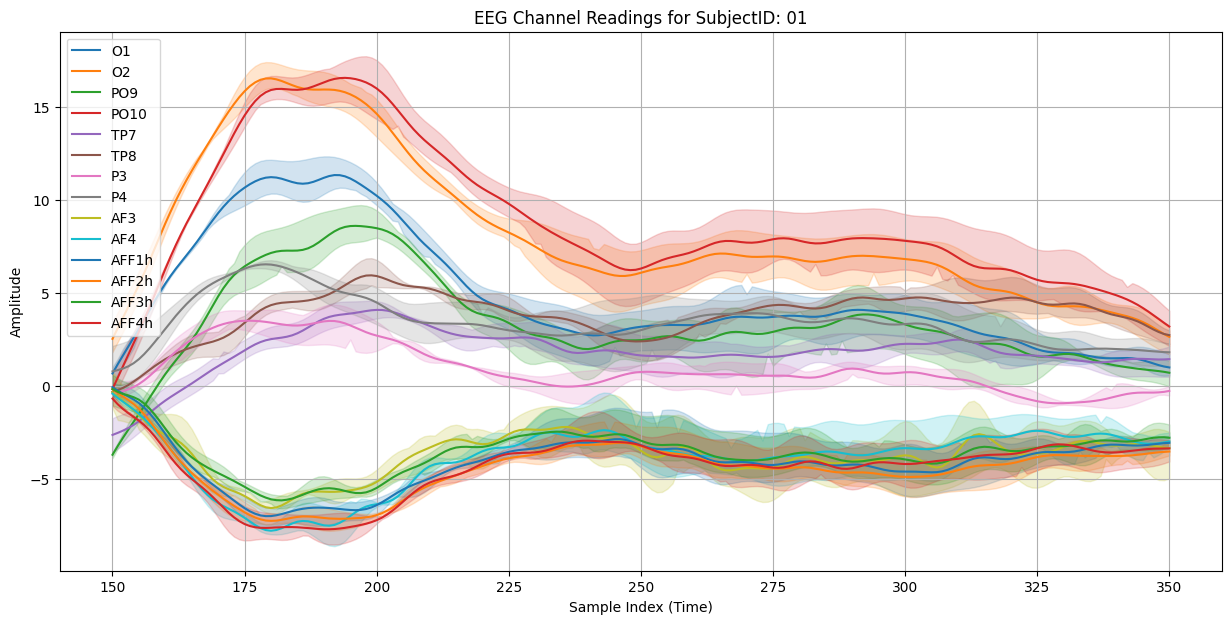

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'reportID' contains the data for SubjectID '01'
# Let's select a few channels to plot
eeg_channels_to_plot = ['O1', 'O2', 'PO9', 'PO10', 'TP7', 'TP8', 'P3', 'P4', 'AF3', 'AF4', 'AFF1h', 'AFF2h', 'AFF3h', 'AFF4h']

plt.figure(figsize=(15, 7))

for channel in eeg_channels_to_plot:
    sns.lineplot(x='SampleIndex', y=channel, data=reportID, label=channel)

plt.title(f'EEG Channel Readings for SubjectID: {reportID["SubjectID"].iloc[0]}')
plt.xlabel('Sample Index (Time)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

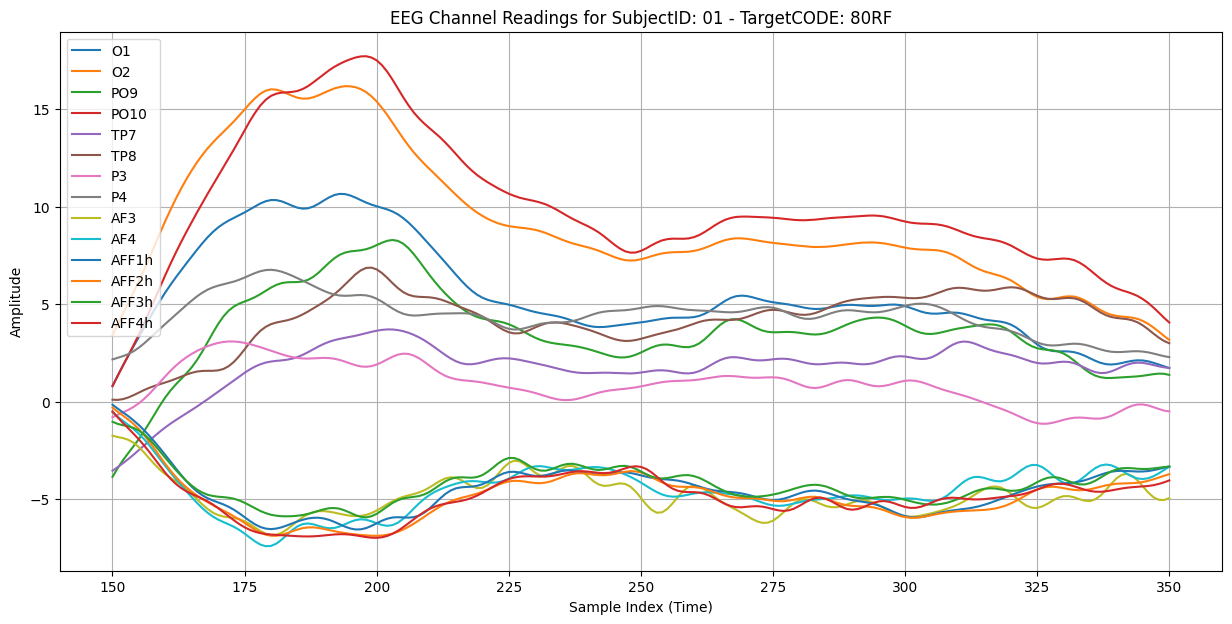

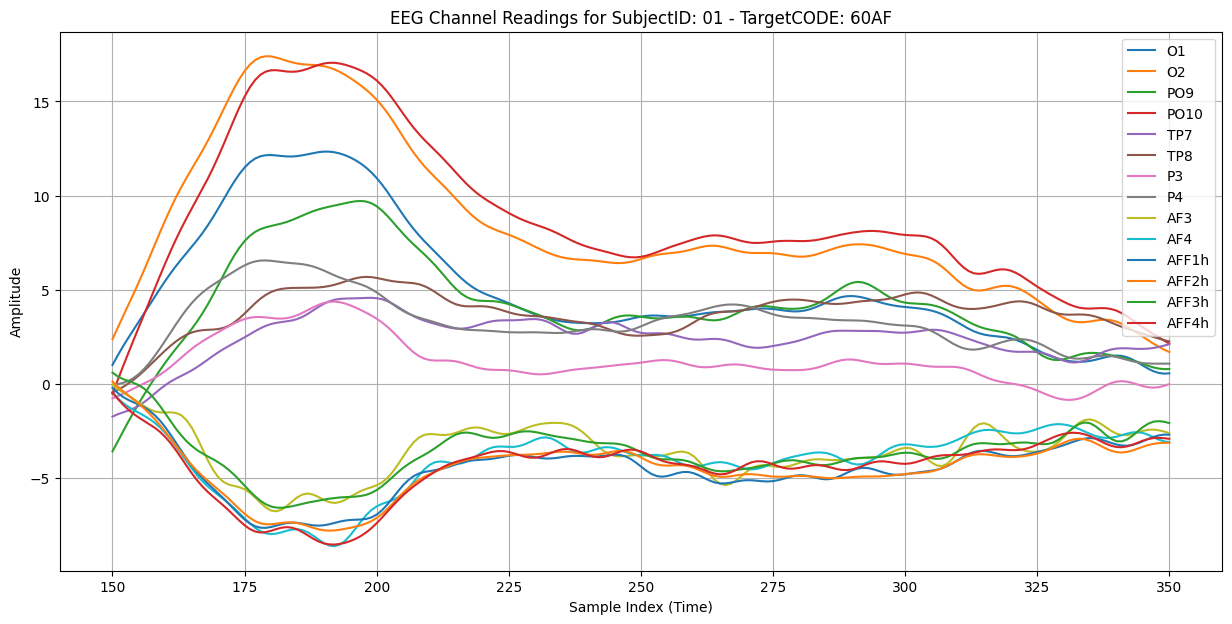

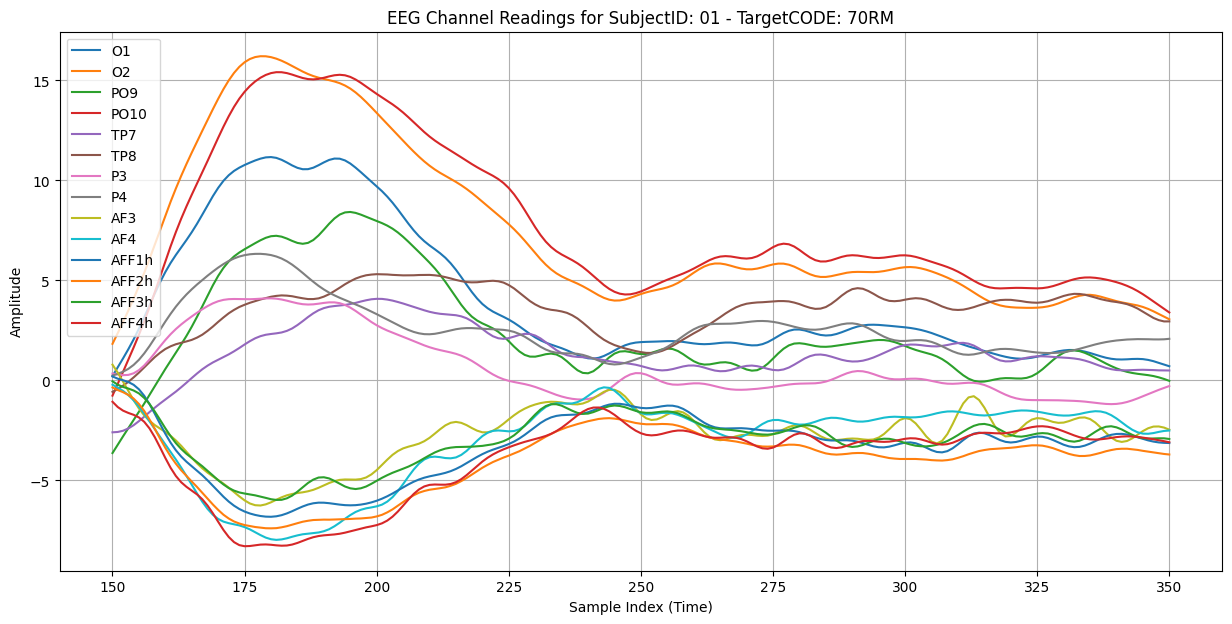

In [ ]:
unique_subject_codes = reportID['TargetCODE'].unique()

for code in unique_subject_codes:
    subset_data = reportID[reportID['TargetCODE'] == code]

    plt.figure(figsize=(15, 7))
    for channel in eeg_channels_to_plot:
        sns.lineplot(x='SampleIndex', y=channel, data=subset_data, label=channel)

    plt.title(f'EEG Channel Readings for SubjectID: {subset_data["SubjectID"].iloc[0]} - TargetCODE: {code}')
    plt.xlabel('Sample Index (Time)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
display(dataset_filtered)

,O1,O2,PO9,PO10,TP7,TP8,P3,P4,AF3,AF4,AFF1h,AFF2h,AFF3h,AFF4h,Trigger,SubjectID,SubjectSEX,TargetCODE,TargetNATURE,SampleIndex
150,-1.23480,0.012061,-0.74995,1.43640,0.170420,-0.98605,1.538800,1.4927,0.74576,-2.17660,-0.54548,-1.5567,0.86463,-2.17000,0.000000,07,1,70RM,0,150
151,-0.20897,0.506880,0.34865,2.11980,0.560510,-0.96014,1.708000,1.4265,-0.10417,-2.14040,-0.83816,-1.7577,0.35893,-2.14740,0.000000,07,1,70RM,0,151
152,0.85957,1.163800,1.45930,2.91940,0.909300,-0.83234,1.902500,1.4362,-1.12070,-2.08820,-1.15140,-1.9768,-0.16184,-2.08690,0.000000,07,1,70RM,0,152
153,1.93550,2.032100,2.51960,3.86640,1.201400,-0.65317,2.126800,1.5297,-2.11440,-2.08630,-1.48980,-2.2249,-0.65774,-2.06550,0.000000,07,1,70RM,0,153
154,2.96070,3.082100,3.48210,4.93450,1.424400,-0.37813,2.374300,1.7078,-2.90160,-2.19780,-1.85540,-2.5032,-1.14530,-2.12750,0.000000,07,1,70RM,0,154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46348,-0.81896,2.804300,-1.03540,0.82060,-0.256700,1.34450,-0.180200,2.0431,-1.03350,0.92176,2.19800,1.2868,-1.07840,-0.53469,-0.003237,28,0,70RM,0,346
46349,-0.70288,2.831700,-0.98024,0.80980,-0.146700,1.23460,-0.128850,1.9852,-0.99953,0.83585,2.19760,1.2752,-1.03660,-0.56956,-0.003237,28,0,70RM,0,347
46350,-0.59315,2.879500,-0.92765,0.81219,-0.056720,1.11360,-0.074644,1.9402,-0.99895,0.77019,2.16120,1.2636,-1.03020,-0.61847,-0.003237,28,0,70RM,0,348
46351,-0.48395,2.926800,-0.87129,0.81395,0.017287,0.98185,-0.019894,1.8982,-1.03000,0.71731,2.08490,1.2437,-1.05820,-0.67633,-0.003237,28,0,70RM,0,349


In [ ]:
print(dataset_filtered['SubjectID'].value_counts())

# Lo salviamo in formato .parquet (più veloce e leggero del .csv per dati EEG)
dataset_filtered.to_parquet('/content/drive/MyDrive/Brain_modeling_project/dataset_eeg_completo.parquet')


SubjectID
07    804
09    804
25    804
08    804
21    804
19    804
10    804
17    804
05    804
27    804
22    804
16    804
04    804
20    804
15    804
02    804
18    804
13    804
26    804
11    804
06    804
12    804
29    804
30    804
28    804
01    603
Name: count, dtype: int64


Rows number for each individual make sense: we actually miss the values for ARTIFICIAL MAN for ID: "01"subject. The result is 603 rows